<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> I love Python

<font color='black'>

- Luis Fernando Márquez Bañuelos

In [1]:
import warnings
import numpy as np
import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray):
    fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)
    
    # Best threshold by minimum distance to top-left corner (0,1)
    distances = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_idx = np.argmin(distances)
    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]
    
    auc_score = roc_auc_score(y_test, probabilidades)
    
    plt.figure(figsize=(10, 5))
    plt.plot(fpr, tpr, c='skyblue', label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], c='indianred', linestyle='--', label='Random')
    
    # Star at best threshold
    plt.scatter(best_fpr, best_tpr, marker='*', s=300, c='gold', zorder=5,
                label=f'Best threshold = {best_threshold:.3f}')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend()
    plt.tight_layout()
    plt.show()

## <font color='cornflowerblue'> Data

In [2]:
data_train = pd.read_csv('data/data1_train.csv')
data_test = pd.read_csv('data/data2_test.csv')

In [3]:
data_train

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1,4500,0,2,28,0,3915,3150,2475,2340,2385,2430,0
1,2,6000,0,2,24,0,2820,2700,2760,2400,2280,2280,1
2,3,3800,0,2,39,0,3572,3648,3762,2166,2204,2242,0
3,4,5500,1,1,27,0,5280,5445,5390,2585,2640,2695,1
4,5,18000,1,1,51,2,3780,3780,3780,1800,1620,720,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,18000,1,1,34,0,180,180,180,180,180,180,0
1996,1997,33300,1,1,34,0,333,333,2664,333,333,2331,0
1997,1998,33000,1,2,35,0,18150,17820,17490,15510,15840,15840,1
1998,1999,18200,1,1,36,0,182,364,0,182,182,182,0


In [4]:
data_test

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1,1500,0,3,31,2,1350,1530,1455,1515,1530,1515,0
1,2,10900,0,1,47,0,8720,9047,9374,0,0,2834,0
2,3,3600,1,2,54,3,2520,2448,2808,2736,2700,2880,1
3,4,4200,0,1,25,0,4116,3990,3906,1764,1722,1722,0
4,5,19200,0,5,53,0,12864,13056,12864,6144,3840,11904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,4200,1,3,53,0,6384,6468,6594,6678,1638,1680,0
996,997,4500,1,2,26,0,1575,540,1485,360,0,0,0
997,998,7300,1,2,28,1,0,0,0,2117,2263,2409,0
998,999,3600,0,3,55,0,1800,1908,1944,1980,2016,2088,0


In [5]:
# Defining the target variable
target = 'default'

# Separating features and target variable
X_train = data_train.copy()
X_test = data_test.copy()

# Features for the model
X_train = X_train.drop(columns=['id', target])
X_test = X_test.drop(columns=['id', target])

# Target variable
y_train = data_train[target]
y_test = data_test[target]

## <font color='cornflowerblue'> EDA

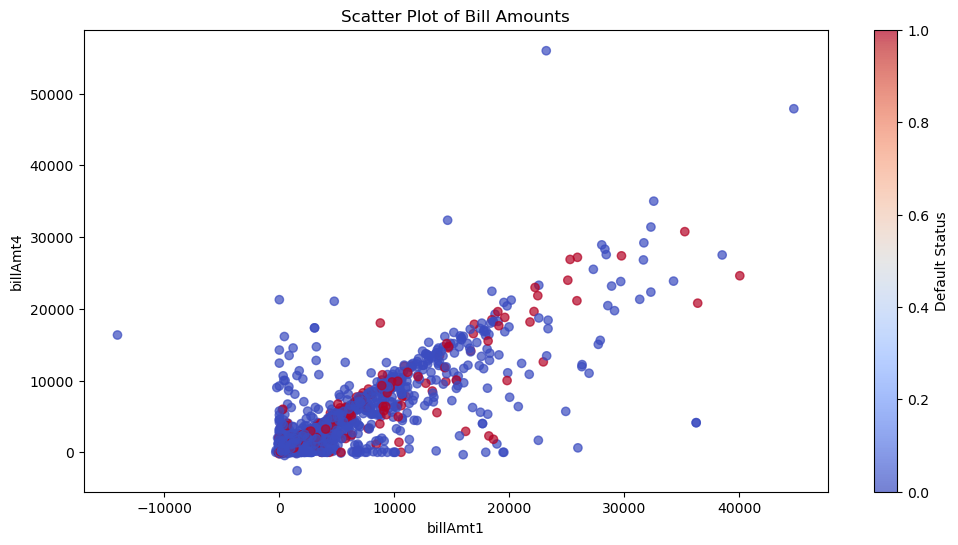

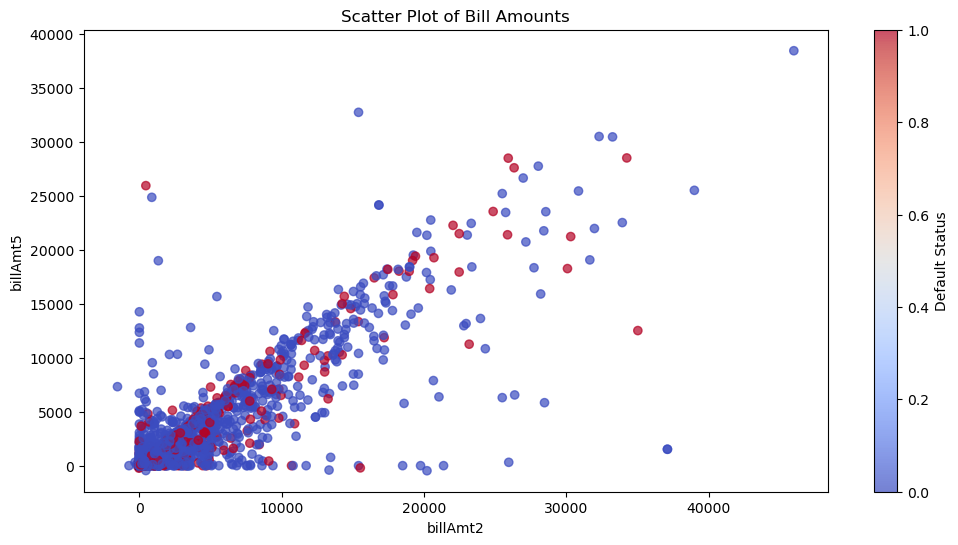

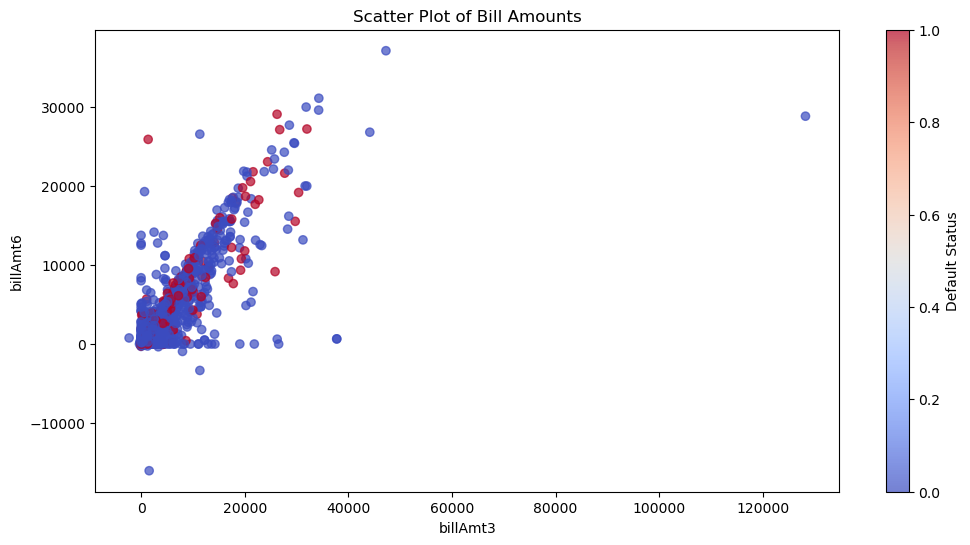

In [6]:
x_scatter = ['billAmt1', 'billAmt2', 'billAmt3']
y_scatter = ['billAmt4', 'billAmt5', 'billAmt6']

for x, y in zip(x_scatter, y_scatter):
    plt.figure(figsize=(12, 6))
    plt.scatter(X_train[x], X_train[y], c=y_train, cmap='coolwarm', alpha=0.7)
    plt.colorbar(label='Default Status')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title('Scatter Plot of Bill Amounts')
    plt.show()

In [7]:
cols = X_train.columns.tolist()

x_dropdown = widgets.Dropdown(options=cols, value=cols[0], description='X axis:')
y_dropdown = widgets.Dropdown(options=cols, value=cols[1], description='Y axis:')

def plot_scatter(x_col, y_col):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        X_train[x_col], 
        X_train[y_col], 
        c=y_train, 
        cmap='coolwarm', 
        alpha=0.7,
        edgecolors='none'
    )
    plt.colorbar(scatter, label='Default Status')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{x_col} vs {y_col}')
    plt.tight_layout()
    plt.show()

widgets.interact(plot_scatter, x_col=x_dropdown, y_col=y_dropdown)

interactive(children=(Dropdown(description='X axis:', options=('creditLimit', 'gender', 'edu', 'age', 'nDelay'…

<function __main__.plot_scatter(x_col, y_col)>

## <font color='cornflowerblue'> Logistic Regression

              precision    recall  f1-score   support

           0       0.78      0.98      0.87       768
           1       0.49      0.07      0.13       232

    accuracy                           0.77      1000
   macro avg       0.63      0.52      0.50      1000
weighted avg       0.71      0.77      0.69      1000



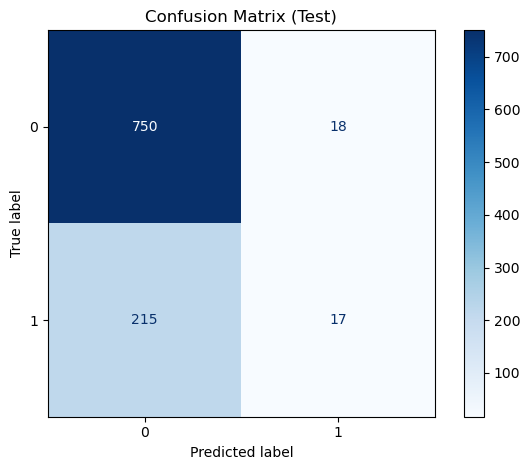

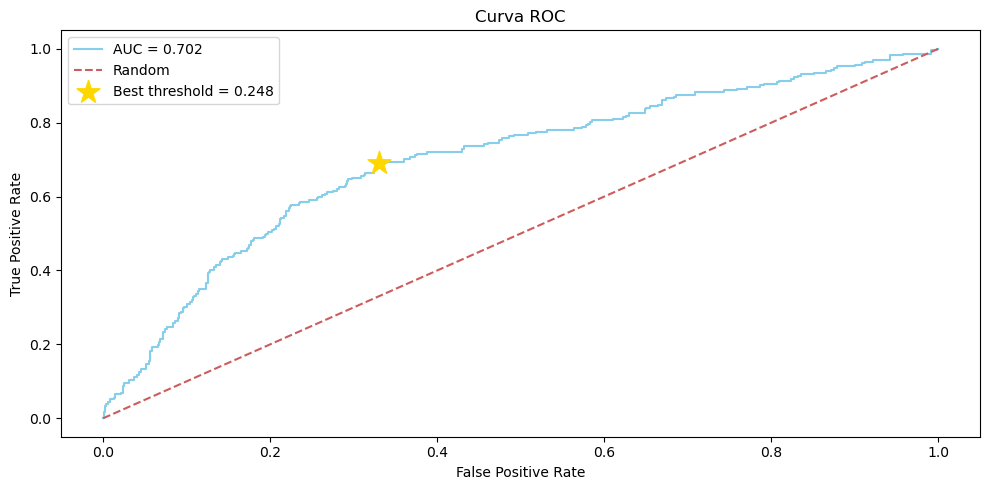

In [8]:
# Logistic Regression
model_log = LogisticRegression()
model_log.fit(X_train, y_train)

# Predictions and probabilities
y_pred_log = model_log.predict(X_test)
y_proba_log = model_log.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

curva_roc(y_proba_log, y_test)

## <font color='cornflowerblue'> XGBoost

              precision    recall  f1-score   support

           0       0.80      0.95      0.86       768
           1       0.52      0.20      0.29       232

    accuracy                           0.77      1000
   macro avg       0.66      0.57      0.58      1000
weighted avg       0.73      0.77      0.73      1000



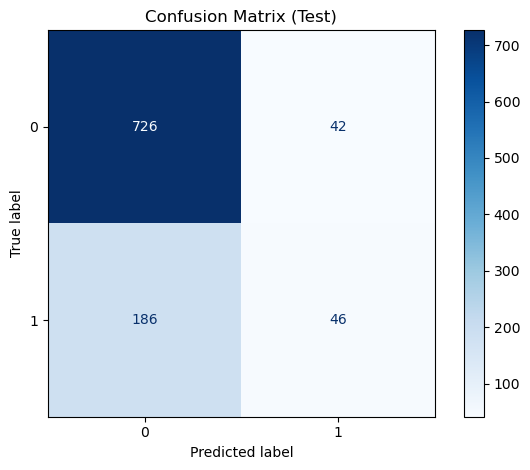

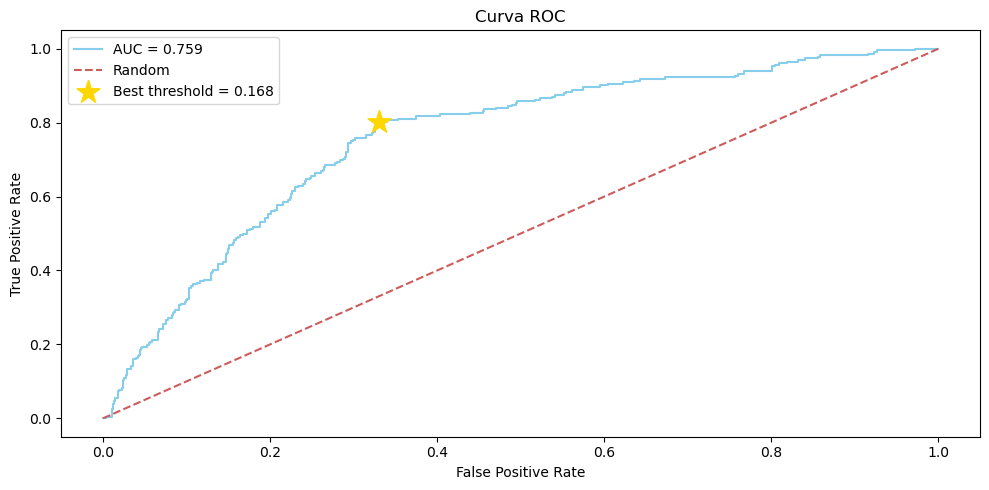

In [9]:
# XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

# Predictions and probabilities
y_pred_log = model.predict(X_test)
y_proba_log = model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

curva_roc(y_proba_log, y_test)